<a href="https://colab.research.google.com/github/houssamak/deeplearning/blob/MLP/Partie_1_MLP_Tabulaire.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

L'objectif de cette première partie est d'étudier les réseaux de neurones multicouches (Multi-Layer Perceptron - MLP) appliqués à un problème de classification supervisée sur des données tabulaires. Pour cela, nous utilisons le dataset Breast Cancer Wisconsin, largement utilisé dans la littérature scientifique pour l'évaluation des algorithmes de classification.

Importation des bibliothèques

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

Chargement du Dataset

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (569, 30)
Shape y : (569,)


Affichage des 5 premieres lignes du dataset

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Préparation des données** :
Nettoyage

In [4]:
print(pd.DataFrame(X).isnull().sum().sum())

0


Encodage : Aucun encodage nécessaire car toutes les variables sont déjà numériques.

Normalisation

In [7]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

Séparation Train / Validation / Test

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

Affichage

In [9]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(398, 30)
(85, 30)
(86, 30)


Conversion en tenseurs

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

Gestion du Device

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device utilisé :", device)

Device utilisé : cpu


MLP avec nn.Sequential

In [12]:
model_seq = nn.Sequential(
    nn.Linear(30,16),
    nn.ReLU(),

    nn.Linear(16,8),
    nn.ReLU(),

    nn.Linear(8,2)
)

print(model_seq)

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=2, bias=True)
)


MLP avec nn.Module

In [13]:
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(30,16)
        self.fc2 = nn.Linear(16,8)
        self.fc3 = nn.Linear(8,2)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x


model = MLP().to(device)

print(model)

MLP(
  (fc1): Linear(in_features=30, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=2, bias=True)
  (relu): ReLU()
)


Vérification des paramètres

In [14]:
model = MLP()

for name, param in model.named_parameters():

    print(name)
    print(param.shape)

fc1.weight
torch.Size([16, 30])
fc1.bias
torch.Size([16])
fc2.weight
torch.Size([8, 16])
fc2.bias
torch.Size([8])
fc3.weight
torch.Size([2, 8])
fc3.bias
torch.Size([2])


Vérification du state_dict

In [15]:
for name, value in model.state_dict().items():

    print(name)
    print(value.shape)

fc1.weight
torch.Size([16, 30])
fc1.bias
torch.Size([16])
fc2.weight
torch.Size([8, 16])
fc2.bias
torch.Size([8])
fc3.weight
torch.Size([2, 8])
fc3.bias
torch.Size([2])


Comparaison des initialisations : Créer une fonction



In [16]:
def initialize_model(method):

    model = MLP()

    if method == "normal":

        for layer in model.modules():
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight)

    elif method == "constant":

        for layer in model.modules():
            if isinstance(layer, nn.Linear):
                nn.init.constant_(layer.weight,0.5)

    elif method == "xavier":

        for layer in model.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)

    return model.to(device)

Fonction d'entraînement

In [17]:
def train_model(model):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(100):

        model.train()

        outputs = model(X_train.to(device))

        loss = criterion(
            outputs,
            y_train.to(device)
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    return losses

Test des 3 initialisations

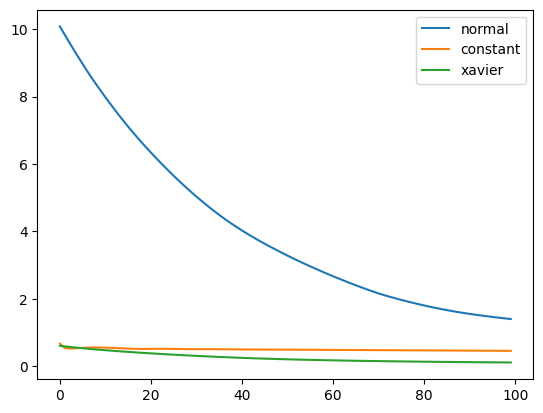

In [18]:
results = {}

for method in ["normal","constant","xavier"]:

    model = initialize_model(method)

    losses = train_model(model)

    model.eval()

    with torch.no_grad():

        preds = model(X_test.to(device))

        preds = torch.argmax(preds,dim=1)

    acc = accuracy_score(
        y_test.cpu(),
        preds.cpu()
    )

    results[method] = acc

    plt.plot(losses,label=method)

plt.legend()
plt.show()

Tableau comparatif

In [19]:
print(results)

{'normal': 0.8023255813953488, 'constant': 0.9418604651162791, 'xavier': 0.9767441860465116}


Vérification du Device

In [20]:
print(next(model.parameters()).device)

print(X_train.to(device).device)

cpu
cpu


Sauvegarde du meilleur modèle

In [22]:
torch.save(
    model.state_dict(),
    "best_mlp.pth"
)

Chargement

In [23]:
model.load_state_dict(
    torch.load("best_mlp.pth")
)

<All keys matched successfully>

Évaluation Finale

In [24]:
model.eval()

with torch.no_grad():

    preds = model(X_test.to(device))

    preds = torch.argmax(preds,dim=1)

In [25]:
accuracy = accuracy_score(
    y_test.cpu(),
    preds.cpu()
)

precision = precision_score(
    y_test.cpu(),
    preds.cpu()
)

recall = recall_score(
    y_test.cpu(),
    preds.cpu()
)

f1 = f1_score(
    y_test.cpu(),
    preds.cpu()
)

print(accuracy)
print(precision)
print(recall)
print(f1)

0.9767441860465116
0.9833333333333333
0.9833333333333333
0.9833333333333333


Matrice de confusion

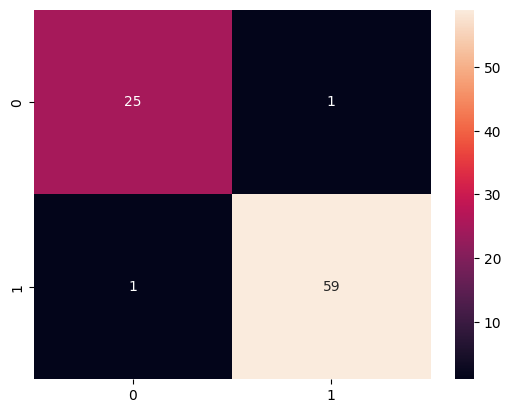

In [26]:
cm = confusion_matrix(
    y_test.cpu(),
    preds.cpu()
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()